In [28]:
from pathlib import Path
import os 
import pandas as pd

cwd = Path.cwd()
num_cov = 2

if cwd.parts[-1] != 'NonLinear_FEMSM':
    os.chdir("..")
    cwd = Path.cwd()

In [29]:
training_index = []
for item in [200,500,1000]:

    df_index = pd.read_parquet(cwd/"results"/"msm"/"seqgplvm"/f"msm_seqgplvm_{item}.parquet")
    df_index = df_index[(df_index.N==item) | (df_index.N==item/4)].reset_index(drop=True)
    #df_index = pd.read_parquet(cwd/"results"/"index"/f"training_{item}.parquet")
    #df_index = df_index[df_index.cfg_N == item*10/8].reset_index(drop=True)

    training_index.append(df_index)


In [30]:
training_index[1]

,batch_id,tau_f_seqgplvm,tau_c_seqgplvm,tau_f_seqgplvm_se,tau_c_seqgplvm_se,tau_f_seqgplvm_imp,tau_c_seqgplvm_imp,tau_f_seqgplvm_se_imp,tau_c_seqgplvm_se_imp,data_id,a,N,T,rho,p,always0,always1,subset,train_id,drop_monotone_model
0,phat_batch_1,1.939292,1.050117,0.220082,0.112006,1.941487,1.052511,0.219253,0.110289,75f923e6,2,500,10,50,4,2,14,train,000f86525f,True
1,phat_batch_2,1.415263,0.731834,0.316584,0.152030,1.420549,0.738284,0.316356,0.152442,75f923e6,2,500,10,50,4,2,14,train,000f86525f,True
2,phat_batch_3,1.312564,0.943128,0.199242,0.108293,1.317308,0.947720,0.198623,0.107487,75f923e6,2,500,10,50,4,2,14,train,000f86525f,True
3,phat_batch_4,2.586910,1.014168,0.469611,0.169534,2.588606,1.016270,0.467378,0.167125,75f923e6,2,500,10,50,4,2,14,train,000f86525f,True
4,phat_batch_5,1.590493,1.028149,0.188671,0.089572,1.593553,1.031796,0.187864,0.088507,75f923e6,2,500,10,50,4,2,14,train,000f86525f,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1211995,phat_batch_97,4.642066,-0.256698,1.297847,0.525243,4.642066,-0.256698,1.297847,0.525243,ae68a7cb,2,125,50,2,4,0,0,val,fff3b0b526,True
1211996,phat_batch_98,4.399394,-0.138459,1.090483,0.482319,4.399394,-0.138459,1.090483,0.482319,ae68a7cb,2,125,50,2,4,0,0,val,fff3b0b526,True
1211997,phat_batch_99,3.791967,-0.063383,1.473770,0.509439,3.791967,-0.063383,1.473770,0.509439,ae68a7cb,2,125,50,2,4,0,0,val,fff3b0b526,True
1211998,phat_batch_100,4.271642,-0.088754,1.361528,0.536415,4.271642,-0.088754,1.361528,0.536415,ae68a7cb,2,125,50,2,4,0,0,val,fff3b0b526,True


In [31]:
#pd.concat(training_index).to_parquet(cwd/"results"/"msm"/"seqgplvm"/f"msm_seqgplvm_all.parquet")
#pd.concat(training_index).to_parquet(cwd/"results"/"index"/f"msm_seqgplvm_all.parquet")

### read seqgplvm results 


In [32]:
df_seqgplvm_results_rw = pd.read_parquet(cwd/"results"/"msm"/"seqgplvm"/"msm_seqgplvm_all.parquet")
df_seqgplvm_results_rw.head()

,batch_id,tau_f_seqgplvm,tau_c_seqgplvm,tau_f_seqgplvm_se,tau_c_seqgplvm_se,tau_f_seqgplvm_imp,tau_c_seqgplvm_imp,tau_f_seqgplvm_se_imp,tau_c_seqgplvm_se_imp,data_id,a,N,T,rho,p,always0,always1,subset,train_id,drop_monotone_model
0,phat_batch_1,1.421541,0.726641,0.242337,0.143027,1.370337,0.659141,0.236122,0.120718,4a0c7a41,1,200,4,50,2,8,40,train,0001f62a89,True
1,phat_batch_2,1.445729,0.700963,0.374278,0.175157,1.348466,0.628295,0.370659,0.161933,4a0c7a41,1,200,4,50,2,8,40,train,0001f62a89,True
2,phat_batch_3,1.367169,0.565795,0.266219,0.170852,1.340216,0.531470,0.244541,0.135850,4a0c7a41,1,200,4,50,2,8,40,train,0001f62a89,True
3,phat_batch_4,1.369913,0.853965,0.307186,0.233954,1.288582,0.779098,0.299730,0.204485,4a0c7a41,1,200,4,50,2,8,40,train,0001f62a89,True
4,phat_batch_5,0.849944,1.051657,0.354388,0.321690,0.787252,0.984465,0.347190,0.296198,4a0c7a41,1,200,4,50,2,8,40,train,0001f62a89,True


In [33]:
import numpy as np
import pandas as pd

mask = (
    df_seqgplvm_results_rw["N"].isin([200, 500, 1000])
    & df_seqgplvm_results_rw["batch_id"].astype(str).str.match(r"^phat_batch_\d+$", na=False)
)
df_seqgplvm_results_rw_bayesian = df_seqgplvm_results_rw.loc[mask].reset_index(drop=True)


# use the filtered df (otherwise you ignore your batch_id mask)
dfb = df_seqgplvm_results_rw_bayesian

bayes_results = (
    dfb[dfb["N"].isin([200, 500, 1000])]
    .groupby(["N", "T", "a", "p", "train_id"], as_index=False)
    .agg(
        M=("tau_c_seqgplvm_imp", "size"),

        # point estimate across posterior draws
        tau_c_bayes_mean=("tau_c_seqgplvm_imp", "mean"),
        tau_f_bayes_mean=("tau_f_seqgplvm_imp", "mean"),

        # between-draw variance B (of the point estimates)
        tau_c_B=("tau_c_seqgplvm_imp", lambda x: np.var(x, ddof=1)),
        tau_f_B=("tau_f_seqgplvm_imp", lambda x: np.var(x, ddof=1)),

        # within-draw variance Wbar = mean(se^2)
        tau_c_Wbar=("tau_c_seqgplvm_se", lambda x: np.mean(np.square(x))),
        tau_f_Wbar=("tau_f_seqgplvm_se", lambda x: np.mean(np.square(x))),
    )
)

# if some groups have M<2, B is NaN; treat as 0 (or drop those groups)
bayes_results[["tau_c_B", "tau_f_B"]] = bayes_results[["tau_c_B", "tau_f_B"]].fillna(0.0)

# total variance + total SE
bayes_results["tau_c_total_var"] = bayes_results["tau_c_Wbar"] + (1 + 1 / bayes_results["M"]) * bayes_results["tau_c_B"]
bayes_results["tau_f_total_var"] = bayes_results["tau_f_Wbar"] + (1 + 1 / bayes_results["M"]) * bayes_results["tau_f_B"]

bayes_results["tau_c_total_se"] = np.sqrt(bayes_results["tau_c_total_var"])
bayes_results["tau_f_total_se"] = np.sqrt(bayes_results["tau_f_total_var"])


bayes_results["seed"] = pd.NA


bayes_results["seed"] = (
    bayes_results
    .groupby(["N", "T", "a", "p"])
    .cumcount() + 1
)

In [34]:
counts = (
    df_seqgplvm_results_rw_bayesian[(df_seqgplvm_results_rw_bayesian.N == 500) | (df_seqgplvm_results_rw_bayesian.N == 200) | (df_seqgplvm_results_rw_bayesian.N == 1000)]
    .groupby(["N","T", "a", "p","train_id"])
    .size()
    .reset_index(name="n_rows")
)

print(counts)

          N    T  a  p    train_id  n_rows
0       200    4  1  2  000107f367     100
1       200    4  1  2  0001f62a89     100
2       200    4  1  2  00274241d6     100
3       200    4  1  2  00357e8386     100
4       200    4  1  2  009195f326     100
...     ...  ... .. ..         ...     ...
17985  1000  200  2  4  fe1b53aff3     100
17986  1000  200  2  4  fe47ff8a7e     100
17987  1000  200  2  4  fe6b62be00     100
17988  1000  200  2  4  feb8056ebb     100
17989  1000  200  2  4  ff6ae0536c     100

[17990 rows x 6 columns]


In [35]:
df_seqgplvm_results_rw = df_seqgplvm_results_rw[(df_seqgplvm_results_rw["N"].isin([200, 500, 1000])) & (df_seqgplvm_results_rw["batch_id"]== "phat_mean")].reset_index(drop=True)

df_seqgplvm_results = (
    df_seqgplvm_results_rw
    .loc[df_seqgplvm_results_rw["N"].isin([200, 500, 1000])]
    .groupby(["N", "T", "a", "p", "train_id"], as_index=False)
    .agg(
        tau_f_seqgplvm      = ("tau_f_seqgplvm", "mean"),
        tau_f_seqgplvm_se   = ("tau_f_seqgplvm_se", "mean"),
        tau_c_seqgplvm      = ("tau_c_seqgplvm", "mean"),
        tau_c_seqgplvm_se   = ("tau_c_seqgplvm_se", "mean"),
        tau_f_seqgplvm_imp    = ("tau_f_seqgplvm_imp", "mean"),
        tau_f_seqgplvm_imp_se = ("tau_f_seqgplvm_se_imp", "mean"),
        tau_c_seqgplvm_imp    = ("tau_c_seqgplvm_imp", "mean"),
        tau_c_seqgplvm_imp_se = ("tau_c_seqgplvm_se_imp", "mean"),
    )
)
df_seqgplvm_results["seed"] = pd.NA


df_seqgplvm_results["seed"] = (
    df_seqgplvm_results
    .groupby(["N", "T", "a", "p"])
    .cumcount() + 1
)

In [36]:
key_cols = ["N", "T", "a", "p", "train_id", "seed"]

bayes_keep = bayes_results[
    ["N", "T", "a", "p", "train_id", "seed",
     "tau_c_bayes_mean", "tau_c_total_se", "tau_c_total_var",
     "tau_f_bayes_mean", "tau_f_total_se", "tau_f_total_var",
     "M", "tau_c_B", "tau_c_Wbar", "tau_f_B", "tau_f_Wbar"]
]

df_seqgplvm_results = (
    df_seqgplvm_results
    .merge(bayes_keep, on=key_cols, how="left", validate="1:1")
)


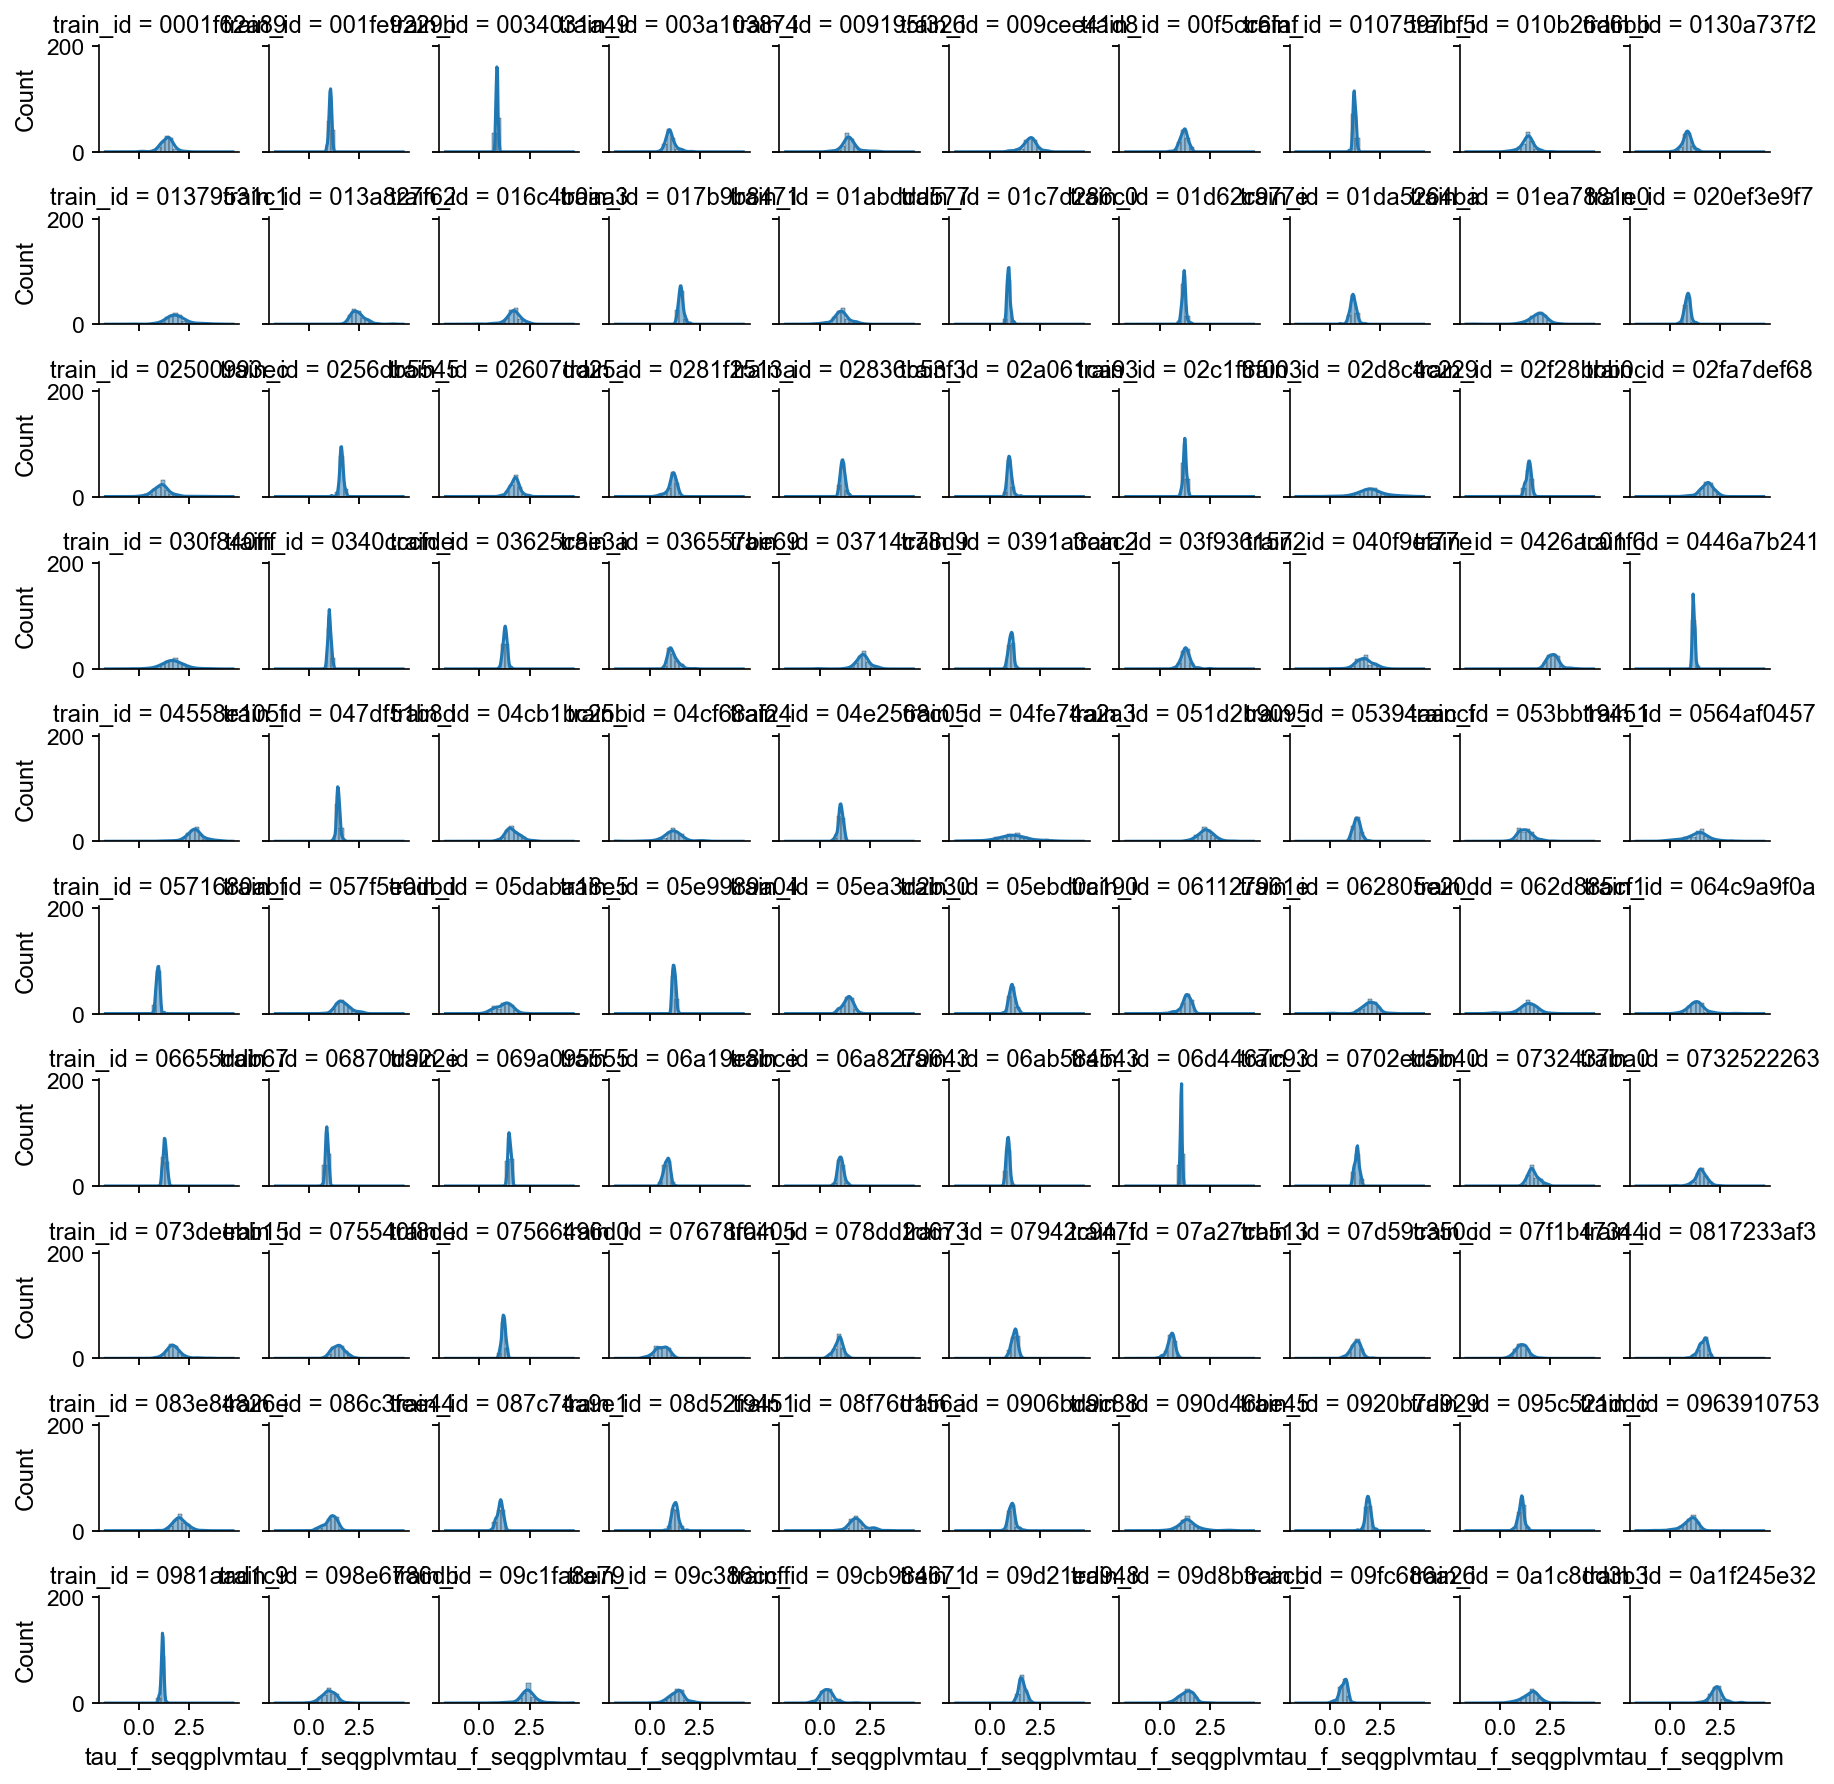

In [37]:
import seaborn as sns

# first 1000 train_id values in the order they appear
first_ids = df_seqgplvm_results_rw_bayesian["train_id"].drop_duplicates().head(100)

df_1000 = df_seqgplvm_results_rw_bayesian[
    df_seqgplvm_results_rw_bayesian["train_id"].isin(first_ids)
]

sns.displot(
    data=df_1000,
    x="tau_f_seqgplvm",
    col="train_id",
    col_wrap=10,      # grid width (10 columns); change as you like
    bins=30,
    kde=True,
    height=1.2,       # size of each small panel
    aspect=1.0
)


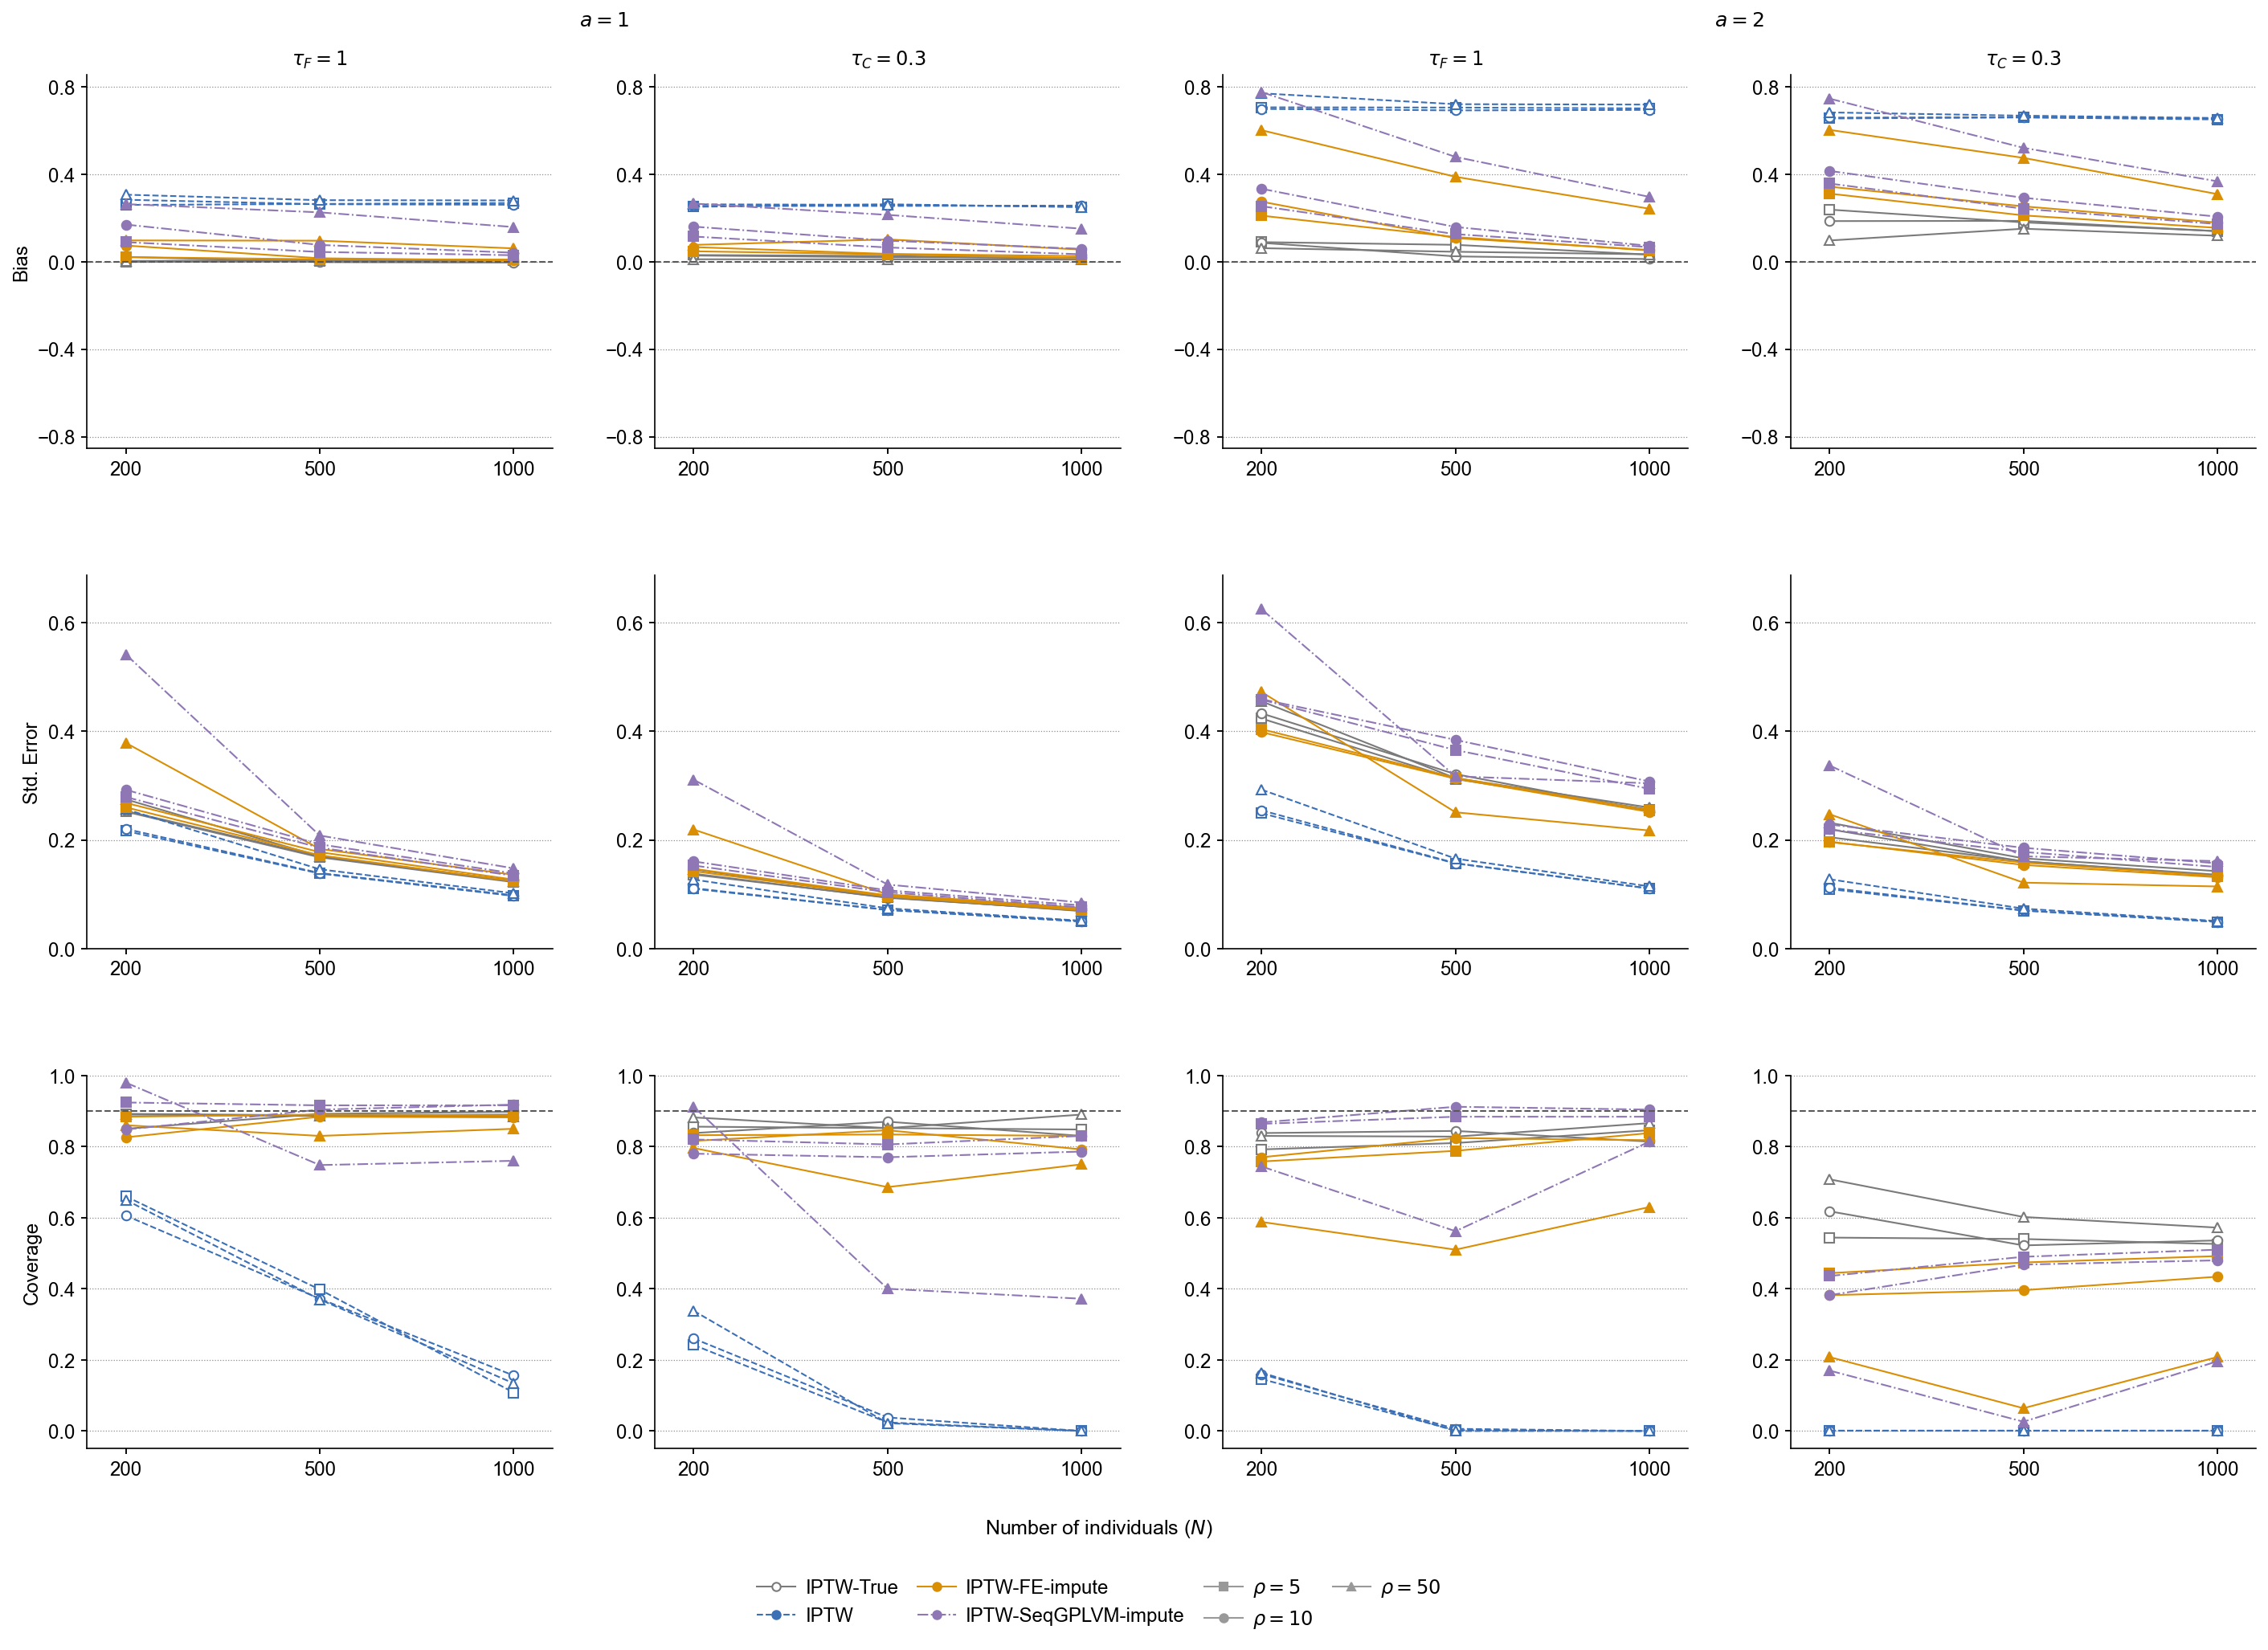

In [ ]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import norm

plt.rcParams.update({
    # Fonts
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "mathtext.fontset": "dejavusans",

    # Font sizes
    "font.size": 10,
    "axes.titlesize": 11.5,
    "axes.labelsize": 11.5,
    "xtick.labelsize": 11.5,
    "ytick.labelsize": 11.5,
    "legend.fontsize": 11.5,

    # Axes / lines
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.6,
    "lines.markersize": 5.5,
    "xtick.major.width": 0.9,
    "ytick.major.width": 0.9,
    "xtick.major.size": 3.5,
    "ytick.major.size": 3.5,

    # Grid
    "grid.linewidth": 0.5,
    "grid.alpha": 0.3,

    # Export
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

df_results = pd.read_csv(cwd/"results"/"msm"/"fe_msm_results_monotone_included.csv")
df_results["tau_c"] = 0.3
df_results["tau_f"] = 1.0

z_90 = norm.ppf(0.95)

# -----------------------------------
# 1) Prepare long data with tau_hats
# -----------------------------------

#keep both a = 1 and a = 2 (only filter on p)
dfp = df_results.loc[(df_results.p == num_cov)].copy()
dfp = dfp.drop(columns=["data_id"]).merge(
    df_seqgplvm_results,
    on=["N", "T", "a", "p", "seed"],
    how="left",
)

dfp = dfp[dfp["N"].isin([200, 500, 1000])].reset_index(drop=True)
#"IPTW-FE",
methods = [ "IPTW-True", "IPTW", "IPTW-FE-impute", "IPTW-SeqGPLVM-impute"]

tau_f_cols = {
    #"IPTW-FE":   "tau_f_fe",
    "IPTW-True": "tau_f_true",
    "IPTW":      "tau_f_no_fe",
    "IPTW-FE-impute":      "tau_f_fe_impute",
    "IPTW-SeqGPLVM-impute": "tau_f_bayes_mean",  
}
tau_c_cols = {
    #"IPTW-FE":   "tau_c_fe",
    "IPTW-True": "tau_c_true",
    "IPTW":      "tau_c_no_fe",
    "IPTW-FE-impute":      "tau_c_fe_impute",
    "IPTW-SeqGPLVM-impute": "tau_c_bayes_mean",
}

rows = []
for _, r in dfp.iterrows():
    for m in methods:
        # τ_F
        rows.append({
            "a":       r["a"],          # NEW: keep a
            "N":       r["N"],
            "rho":     r["rho"],
            "param":   r"$\tau_F = 1$",
            "method":  m,
            "tau_hat": r[tau_f_cols[m]],
            "tau_true": r["tau_f"],
            "seed":    r["seed"],
            "se_hat":  r[{#"IPTW-FE":"tau_f_fe_se",
                         "IPTW-True":"tau_f_true_se",
                         "IPTW":"tau_f_no_fe_se",
                         "IPTW-FE-impute": "tau_f_fe_impute_se",
                        "IPTW-SeqGPLVM-impute": "tau_f_total_se",
                         }[m]]
        })
        # τ_C
        rows.append({
            "a":       r["a"],          
            "N":       r["N"],
            "rho":     r["rho"],
            "param":   r"$\tau_C = 0.3$",
            "method":  m,
            "tau_hat": r[tau_c_cols[m]],
            "tau_true": r["tau_c"],
            "seed":    r["seed"],
            "se_hat":  r[{"IPTW-FE":"tau_c_fe_se",
                         "IPTW-True":"tau_c_true_se",
                         "IPTW":"tau_c_no_fe_se",
                         "IPTW-FE-impute": "tau_c_fe_impute_se", 
                         "IPTW-SeqGPLVM-impute": "tau_c_total_se",
                         }[m]]
        })

long_df = pd.DataFrame(rows).sort_values(["a", "param", "method", "rho", "N"])

# diffs per simulation
long_df["diff"] = long_df["tau_hat"] - long_df["tau_true"]
long_df["abs_diff"] = long_df["diff"].abs()

# 90% Wald CI using HC2 SEs
long_df["ci_low"]  = long_df["tau_hat"] - z_90 * long_df["se_hat"]
long_df["ci_high"] = long_df["tau_hat"] + z_90 * long_df["se_hat"]
long_df["covered"] = (
    (long_df["tau_true"] >= long_df["ci_low"]) &
    (long_df["tau_true"] <= long_df["ci_high"])
).astype(float)

# -----------------------------------
# 2) Aggregate over seeds
# -----------------------------------
agg_df = (
    long_df
    .groupby(["a", "N", "rho", "param", "method"], as_index=False)  # NEW: include a
    .agg(
        bias_abs=("abs_diff", "mean"),   # mean |bias|
        mc_sd=("tau_hat", "std"), # MC std of estimator
        avg_se=("se_hat", "mean"),      
        bias = ("diff", "mean"),         # mean bias
        coverage = ("covered", "mean")
    )
)

# compute common y-limits within each row
bias_max = agg_df["bias"].abs().max()
se_max = agg_df["avg_se"].max()

bias_lim = 1.1 * bias_max if bias_max > 0 else 0.1
se_lim = 1.1 * se_max if se_max > 0 else 0.1

# coverage limits based on the actual data
cov_min = agg_df["coverage"].min()
cov_max = agg_df["coverage"].max()
cov_pad = max(0.02, 0.05 * (cov_max - cov_min))

cov_low = max(0.0, min(cov_min, 0.9) - cov_pad)
cov_high = min(1.0, max(cov_max, 0.9) + cov_pad)

# -----------------------------------
# 3) Plot: 3 rows (bias, std, coverage) × 4 cols (a=1,2 × τ_F, τ_C)
# -----------------------------------
method_ls = {
    "IPTW-True": "-",
    "IPTW": "--",
    "IPTW-FE-impute": "-",
    "IPTW-SeqGPLVM-impute": "-."
}
method_color = {
    "IPTW-True": "#7A7A7A",
    "IPTW": "#3B6FB6",
    "IPTW-FE-impute": "#D98E04",
    "IPTW-SeqGPLVM-impute": "#8F77B5",
}
rho_markers  = {5: "s", 10: "o", 50: "^"}

# NEW: 3 rows x 4 columns
fig, axes = plt.subplots(3, 4, figsize=(20, 15), sharex=False, sharey=False)

params = [r"$\tau_F = 1$", r"$\tau_C = 0.3$"]
a_vals = sorted(agg_df["a"].unique())   # expects [1, 2]

unique_N = sorted(agg_df["N"].unique())
xpos = {n: i for i, n in enumerate(unique_N)}

rowspecs = [
    (0, "bias",      "Bias"),
    (1, "avg_se",   "Std. Error"),
    (2, "coverage",  "Coverage"),
]

for row_idx, metric_col, ylabel in rowspecs:
    for a_idx, a_val in enumerate(a_vals):
        for p_idx, param in enumerate(params):
            col_idx = 2 * a_idx + p_idx   # 0,1 -> a=1 ; 2,3 -> a=2
            ax = axes[row_idx, col_idx]

            # subset for this (a, param)
            sub = agg_df[(agg_df["a"] == a_val) & (agg_df["param"] == param)]

            for method in methods:
                for rho, g in sub[sub["method"] == method].groupby("rho"):
                    x = g["N"].map(xpos)
                    ax.plot(
                        x,
                        g[metric_col],
                        linestyle=method_ls[method],
                        color=method_color[method],
                        marker=rho_markers.get(rho, "o"),
                        markerfacecolor=(
                            "white" if method in ("IPTW-True", "IPTW") else method_color[method]
                        ),
                        lw=1,
                        markersize=5.5,
                    )

            ax.set_xticks(range(len(unique_N)))
            ax.set_xticklabels(unique_N)
            ax.set_xlim(-0.2, len(unique_N) - 0.8)
            ax.tick_params(axis="y")
            # Only left-most column gets a y-label
            if col_idx == 0:
                ax.set_ylabel(ylabel)
            else:
                ax.set_ylabel("")
           

            if row_idx == 0:
                ax.set_title(rf"{param}", pad=6)

            # cleaner panels
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            #ax.grid(True, axis="y", linestyle=":", alpha=0.35)
            ax.grid(True, axis="y", linestyle=":", color="0.50", linewidth=0.6, alpha=0.9)
            ax.grid(False, axis="x")

            # Horizontal reference lines
            if metric_col == "bias":
                ax.axhline(0.0, color="0.35", linestyle="--", linewidth=1)
                ax.set_ylim(-bias_lim, bias_lim)
                ax.set_yticks(np.arange(-0.8, 0.81, 0.4))

            elif metric_col == "avg_se":
                ax.set_ylim(0, se_lim)
                ax.set_yticks(np.arange(0, 0.61, 0.2))

            elif metric_col == "coverage":
                ax.axhline(0.9, color="0.35", linestyle="--", linewidth=1)
                ax.set_ylim(-0.05, 1.0)
                ax.set_yticks(np.arange(0, 1.01, 0.2))

# -----------------------------------
# 4) One combined legend outside
# -----------------------------------
method_handles = [
    #Line2D([0],[0], color=method_color["IPTW-FE"],   linestyle="-",  marker="o", lw=1, markersize=5, label="IPTW-FE"),
    Line2D([0],[0], color=method_color["IPTW-True"], linestyle=method_ls["IPTW-True"],  marker="o", lw=1, markersize=5,
           markerfacecolor="white", label="IPTW-True"),
    Line2D([0],[0], color=method_color["IPTW"],      linestyle=method_ls["IPTW"], marker="o", lw=1, markersize=5, label="IPTW"),
    Line2D([0],[0], color=method_color["IPTW-FE-impute"],      linestyle=method_ls["IPTW-FE-impute"], marker="o", lw=1, markersize=5, label="IPTW-FE-impute"),
    Line2D([0],[0], color=method_color["IPTW-SeqGPLVM-impute"],      linestyle=method_ls["IPTW-SeqGPLVM-impute"], marker="o", lw=1, markersize=5, label="IPTW-SeqGPLVM-impute"),
]
shape_handles = [
    Line2D([0],[0], color="0.6", linestyle="-", marker="s", lw=1, markersize=5, label=r"$\rho=5$"),
    Line2D([0],[0], color="0.6", linestyle="-", marker="o", lw=1, markersize=5, label=r"$\rho=10$"),
    Line2D([0],[0], color="0.6", linestyle="-", marker="^", lw=1, markersize=5, label=r"$\rho=50$"),
]
all_handles = method_handles + shape_handles
all_labels  = [h.get_label() for h in all_handles]

fig.legend(
    all_handles, all_labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.05),   
    frameon=False,
    ncol=4,
    columnspacing=1.0,
    handletextpad=0.5,
)
fig.subplots_adjust(
    left=0.08, right=0.98, top=0.92, bottom=0.16,
    hspace=0.34, wspace=0.22
)
# centers of the 4 columns in figure coordinates
col_centers = []
for j in range(4):
    pos = axes[0, j].get_position()
    col_centers.append((pos.x0 + pos.x1) / 2)

# center of columns (0,1) and (2,3)
a1_center = (col_centers[0] + col_centers[1]) / 2
a2_center = (col_centers[2] + col_centers[3]) / 2

# vertical position slightly above the top row
top_y = axes[0, 0].get_position().y1 + 0.025

fig.text(a1_center, top_y, r"$a=1$", ha="center", va="bottom", fontsize=12)
fig.text(a2_center, top_y, r"$a=2$", ha="center", va="bottom", fontsize=12)
#fig.subplots_adjust(right=0.82, hspace=0.3, wspace=0.25)
fig.supxlabel(r"Number of individuals ($N$)", y=0.11)   # move x-title upward
#fig.savefig(r"g:\My Drive\Courses\MasterThesis\Code\NonLinear_FEMSM\paper\figures\build\simulation_results.pdf", bbox_inches="tight")
plt.show()


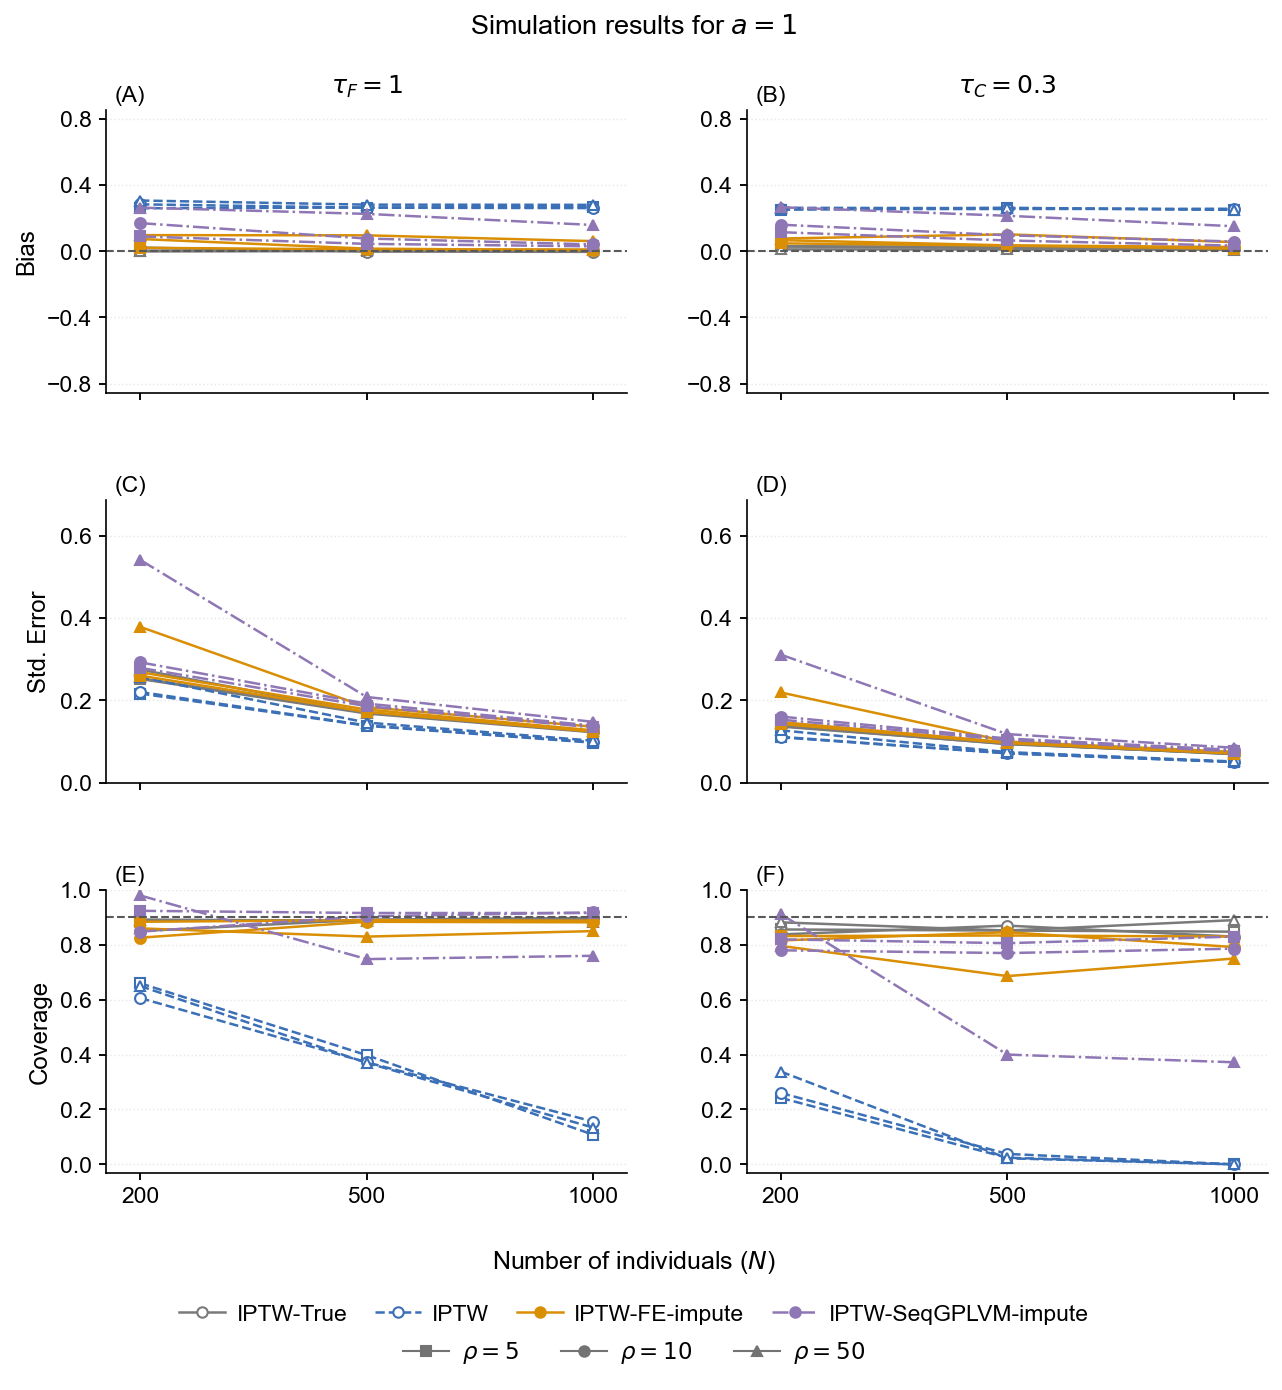

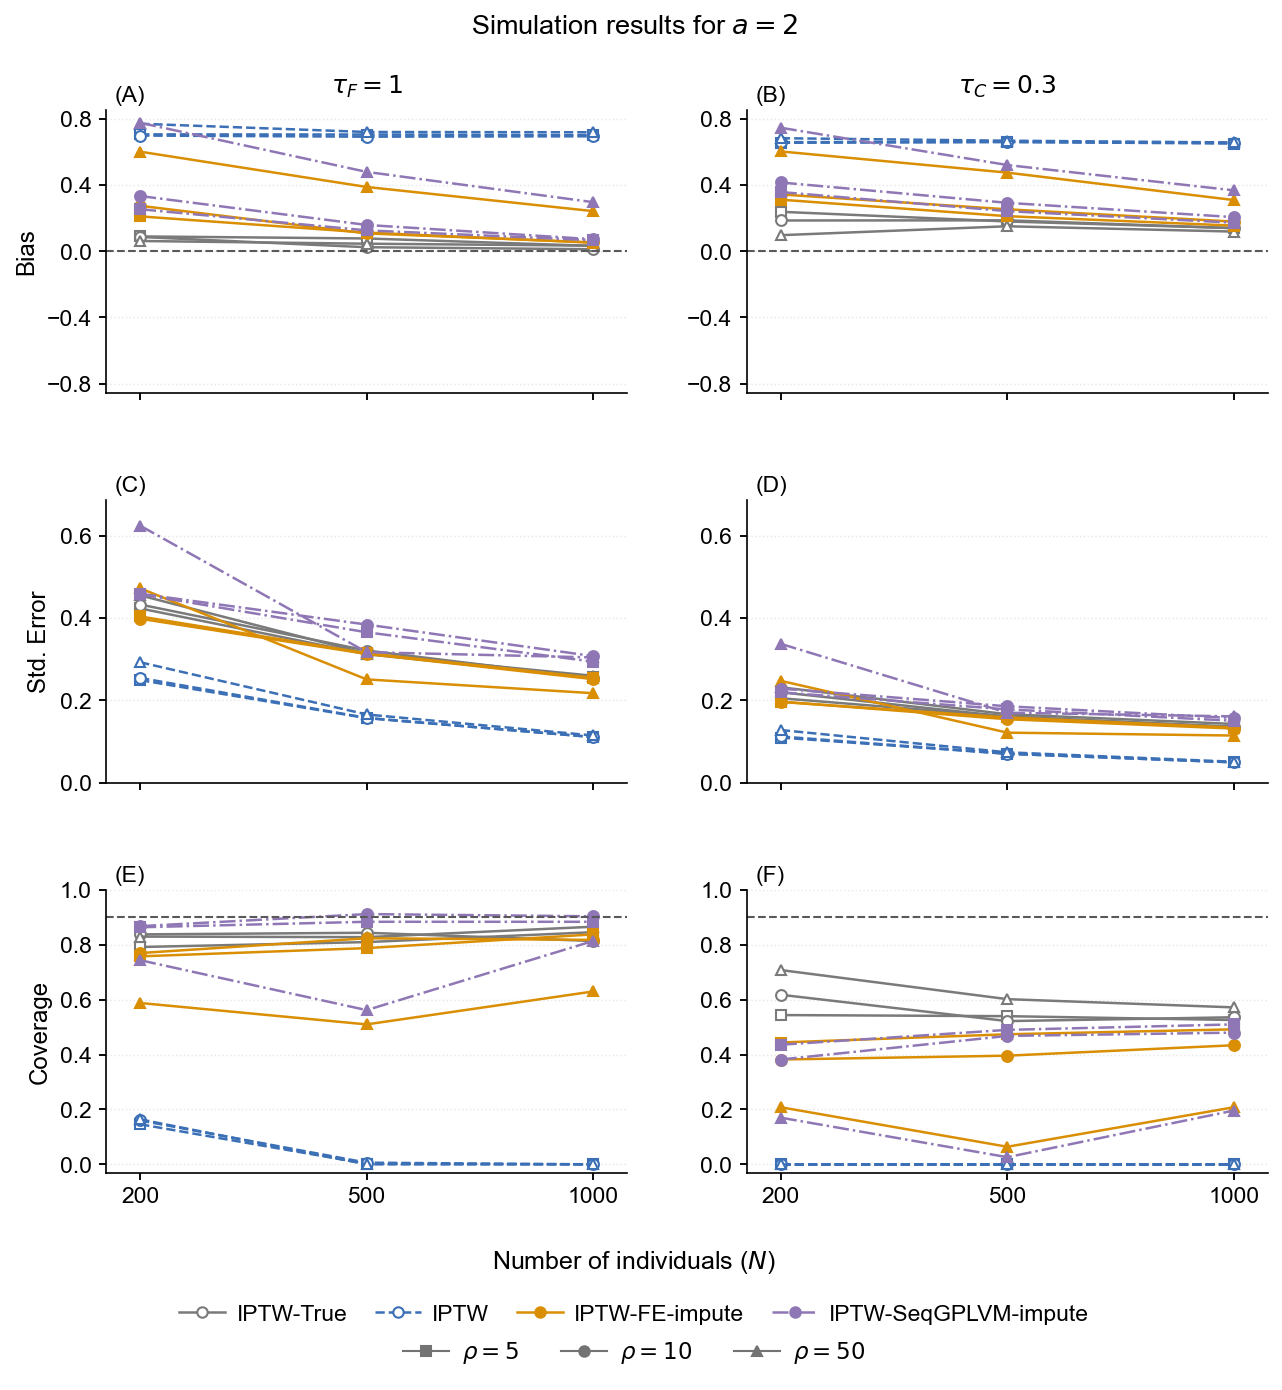

In [38]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import norm

plt.rcParams.update({
    # Fonts
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "mathtext.fontset": "dejavusans",

    # Font sizes
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 11.5,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,

    # Axes / lines
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.5,
    "lines.markersize": 5.5,
    "xtick.major.width": 0.9,
    "ytick.major.width": 0.9,
    "xtick.major.size": 3.5,
    "ytick.major.size": 3.5,

    # Grid
    "grid.linewidth": 0.5,
    "grid.alpha": 0.3,

    # Clean white figure background
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",

    # Export
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

df_results = pd.read_csv(cwd / "results" / "msm" / "fe_msm_results_monotone_included.csv")
df_results["tau_c"] = 0.3
df_results["tau_f"] = 1.0

z_90 = norm.ppf(0.95)

# -----------------------------------
# 1) Prepare long data with tau_hats
# -----------------------------------

# keep both a = 1 and a = 2 (only filter on p)
dfp = df_results.loc[(df_results.p == num_cov)].copy()
dfp = dfp.drop(columns=["data_id"]).merge(
    df_seqgplvm_results,
    on=["N", "T", "a", "p", "seed"],
    how="left",
)

dfp = dfp[dfp["N"].isin([200, 500, 1000])].reset_index(drop=True)

methods = ["IPTW-True", "IPTW", "IPTW-FE-impute", "IPTW-SeqGPLVM-impute"]

tau_f_cols = {
    "IPTW-True": "tau_f_true",
    "IPTW": "tau_f_no_fe",
    "IPTW-FE-impute": "tau_f_fe_impute",
    "IPTW-SeqGPLVM-impute": "tau_f_bayes_mean",
}
tau_c_cols = {
    "IPTW-True": "tau_c_true",
    "IPTW": "tau_c_no_fe",
    "IPTW-FE-impute": "tau_c_fe_impute",
    "IPTW-SeqGPLVM-impute": "tau_c_bayes_mean",
}

se_f_cols = {
    "IPTW-True": "tau_f_true_se",
    "IPTW": "tau_f_no_fe_se",
    "IPTW-FE-impute": "tau_f_fe_impute_se",
    "IPTW-SeqGPLVM-impute": "tau_f_total_se",
}
se_c_cols = {
    "IPTW-True": "tau_c_true_se",
    "IPTW": "tau_c_no_fe_se",
    "IPTW-FE-impute": "tau_c_fe_impute_se",
    "IPTW-SeqGPLVM-impute": "tau_c_total_se",
}

rows = []
for _, r in dfp.iterrows():
    for m in methods:
        # tau_F
        rows.append({
            "a": r["a"],
            "N": r["N"],
            "rho": r["rho"],
            "param": r"$\tau_F = 1$",
            "method": m,
            "tau_hat": r[tau_f_cols[m]],
            "tau_true": r["tau_f"],
            "seed": r["seed"],
            "se_hat": r[se_f_cols[m]],
        })
        # tau_C
        rows.append({
            "a": r["a"],
            "N": r["N"],
            "rho": r["rho"],
            "param": r"$\tau_C = 0.3$",
            "method": m,
            "tau_hat": r[tau_c_cols[m]],
            "tau_true": r["tau_c"],
            "seed": r["seed"],
            "se_hat": r[se_c_cols[m]],
        })

long_df = pd.DataFrame(rows).sort_values(["a", "param", "method", "rho", "N"])

# diffs per simulation
long_df["diff"] = long_df["tau_hat"] - long_df["tau_true"]
long_df["abs_diff"] = long_df["diff"].abs()

# 90% Wald CI using HC2 SEs
long_df["ci_low"] = long_df["tau_hat"] - z_90 * long_df["se_hat"]
long_df["ci_high"] = long_df["tau_hat"] + z_90 * long_df["se_hat"]
long_df["covered"] = (
    (long_df["tau_true"] >= long_df["ci_low"]) &
    (long_df["tau_true"] <= long_df["ci_high"])
).astype(float)

# -----------------------------------
# 2) Aggregate over seeds
# -----------------------------------
agg_df = (
    long_df
    .groupby(["a", "N", "rho", "param", "method"], as_index=False)
    .agg(
        bias_abs=("abs_diff", "mean"),
        mc_sd=("tau_hat", "std"),
        avg_se=("se_hat", "mean"),
        bias=("diff", "mean"),
        coverage=("covered", "mean"),
    )
)

# Common y-limits across BOTH figures for comparability
bias_max = agg_df["bias"].abs().max()
se_max = agg_df["avg_se"].max()

bias_lim = 1.1 * bias_max if bias_max > 0 else 0.1
se_lim = 1.1 * se_max if se_max > 0 else 0.1

# You can also hard-code these if you prefer
bias_ticks = np.arange(-0.8, 0.81, 0.4)
se_ticks = np.arange(0, 0.61, 0.2)
cov_ticks = np.arange(0, 1.01, 0.2)

# -----------------------------------
# 3) Plot styling
# -----------------------------------
method_ls = {
    "IPTW-True": "-",
    "IPTW": "--",
    "IPTW-FE-impute": "-",
    "IPTW-SeqGPLVM-impute": "-.",
}
method_color = {
    "IPTW-True": "#7A7A7A",
    "IPTW": "#3B6FB6",
    "IPTW-FE-impute": "#D98E04",
    "IPTW-SeqGPLVM-impute": "#8F77B5",
}
rho_markers = {5: "s", 10: "o", 50: "^"}

params = [r"$\tau_F = 1$", r"$\tau_C = 0.3$"]
unique_N = sorted(agg_df["N"].unique())
xpos = {n: i for i, n in enumerate(unique_N)}

rowspecs = [
    ("bias", "Bias"),
    ("avg_se", "Std. Error"),
    ("coverage", "Coverage"),
]

panel_labels = ["(A)", "(B)", "(C)", "(D)", "(E)", "(F)"]

def make_figure_for_a(a_val, save_path=None):
    sub_df = agg_df[agg_df["a"] == a_val].copy()

    fig, axes = plt.subplots(
        3, 2,
        figsize=(8.8, 9.2),
        sharex=True,
        sharey=False,
    )

    label_idx = 0

    for row_idx, (metric_col, ylabel) in enumerate(rowspecs):
        for col_idx, param in enumerate(params):
            ax = axes[row_idx, col_idx]
            panel_df = sub_df[sub_df["param"] == param]

            for method in methods:
                method_df = panel_df[panel_df["method"] == method]
                for rho, g in method_df.groupby("rho"):
                    g = g.sort_values("N")
                    x = g["N"].map(xpos)

                    ax.plot(
                        x,
                        g[metric_col],
                        linestyle=method_ls[method],
                        color=method_color[method],
                        marker=rho_markers.get(rho, "o"),
                        markerfacecolor=(
                            "white" if method in ("IPTW-True", "IPTW") else method_color[method]
                        ),
                        markeredgecolor=method_color[method],
                        markeredgewidth=1.0,
                        lw=1.2,
                        markersize=5.2,
                    )

            ax.set_xticks(range(len(unique_N)))
            ax.set_xticklabels(unique_N)
            ax.set_xlim(-0.15, len(unique_N) - 0.85)

            if col_idx == 0:
                ax.set_ylabel(ylabel)

            if row_idx == 0:
                ax.set_title(param, pad=8)

            # Panel label
            ax.annotate(
            panel_labels[label_idx],
            xy=(0, 1),
            xycoords="axes fraction",
            xytext=(4, 2),
            textcoords="offset points",
            ha="left",
            va="bottom",
            fontsize=11,
            annotation_clip=False,
        )
            label_idx += 1

            # Clean professional look
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.grid(True, axis="y", linestyle=":", color="0.70", linewidth=0.7)
            ax.grid(False, axis="x")
            ax.set_facecolor("white")

            # Metric-specific formatting
            if metric_col == "bias":
                ax.axhline(0.0, color="0.35", linestyle="--", linewidth=1)
                ax.set_ylim(-bias_lim, bias_lim)
                ax.set_yticks(bias_ticks)

            elif metric_col == "avg_se":
                ax.set_ylim(0, se_lim)
                ax.set_yticks(se_ticks)

            elif metric_col == "coverage":
                ax.axhline(0.9, color="0.35", linestyle="--", linewidth=1)
                ax.set_ylim(-0.03, 1.0)
                ax.set_yticks(cov_ticks)

    # Figure-level label instead of floating block labels
    fig.suptitle(rf"Simulation results for $a={a_val}$", y=0.999, fontsize=13)

    # Shared x-label
    fig.supxlabel(r"Number of individuals ($N$)", y=0.085)

    # Separate legends: one for methods, one for rho
    method_handles = [
        Line2D(
            [0], [0],
            color=method_color["IPTW-True"],
            linestyle=method_ls["IPTW-True"],
            marker="o",
            lw=1.2,
            markersize=5,
            markerfacecolor="white",
            markeredgecolor=method_color["IPTW-True"],
            label="IPTW-True",
        ),
        Line2D(
            [0], [0],
            color=method_color["IPTW"],
            linestyle=method_ls["IPTW"],
            marker="o",
            lw=1.2,
            markersize=5,
            markerfacecolor="white",
            markeredgecolor=method_color["IPTW"],
            label="IPTW",
        ),
        Line2D(
            [0], [0],
            color=method_color["IPTW-FE-impute"],
            linestyle=method_ls["IPTW-FE-impute"],
            marker="o",
            lw=1.2,
            markersize=5,
            markerfacecolor=method_color["IPTW-FE-impute"],
            markeredgecolor=method_color["IPTW-FE-impute"],
            label="IPTW-FE-impute",
        ),
        Line2D(
            [0], [0],
            color=method_color["IPTW-SeqGPLVM-impute"],
            linestyle=method_ls["IPTW-SeqGPLVM-impute"],
            marker="o",
            lw=1.2,
            markersize=5,
            markerfacecolor=method_color["IPTW-SeqGPLVM-impute"],
            markeredgecolor=method_color["IPTW-SeqGPLVM-impute"],
            label="IPTW-SeqGPLVM-impute",
        ),
    ]

    rho_handles = [
        Line2D([0], [0], color="0.45", linestyle="-", marker="s", lw=1.0, markersize=5, label=r"$\rho = 5$"),
        Line2D([0], [0], color="0.45", linestyle="-", marker="o", lw=1.0, markersize=5, label=r"$\rho = 10$"),
        Line2D([0], [0], color="0.45", linestyle="-", marker="^", lw=1.0, markersize=5, label=r"$\rho = 50$"),
    ]

    fig.legend(
        handles=method_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.035),
        ncol=4,
        frameon=False,
        columnspacing=1.2,
        handletextpad=0.5,
    )

    fig.legend(
        handles=rho_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.005),
        ncol=3,
        frameon=False,
        columnspacing=1.8,
        handletextpad=0.6,
    )

    fig.subplots_adjust(
    left=0.10,
    right=0.98,
    top=0.93,
    bottom=0.16,
    hspace=0.38,
    wspace=0.23,
)

    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")

    return fig, axes

# -----------------------------------
# 4) Create one figure per a
# -----------------------------------
fig1, axes1 = make_figure_for_a(
    a_val=1,
    save_path=rf"g:\My Drive\Courses\MasterThesis\Code\NonLinear_FEMSM\paper\figures\build\simulation_results_a1_p{num_cov}.pdf"
)

fig2, axes2 = make_figure_for_a(
    a_val=2,
    save_path=rf"g:\My Drive\Courses\MasterThesis\Code\NonLinear_FEMSM\paper\figures\build\simulation_results_a2_p{num_cov}.pdf"
)

plt.show()

# Tables

In [39]:
from pathlib import Path
import pandas as pd
import re
import unicodedata

method_order = ["IPTW-True", "IPTW", "IPTW-FE-impute", "IPTW-SeqGPLVM-impute"]
rho_order = sorted(agg_df["rho"].unique())
N_order = [200, 500, 1000]

metric_names = {"bias": "Bias", "mc_sd": "MC SD", "avg_se": "Avg SE", "coverage": "Cov"}

def slugify(s: str) -> str:
    s = s.replace("τ", "tau").replace("ρ", "rho")
    s = unicodedata.normalize("NFKD", s)
    s = s.encode("ascii", "ignore").decode("ascii")
    s = s.lower()
    s = re.sub(r"[^a-z0-9]+", "_", s).strip("_")
    return s

def strip_to_tabular(latex: str) -> str:
    m = re.search(r"(\\begin\{tabular\}.*?\\end\{tabular\})", latex, flags=re.S)
    return m.group(1) if m else latex

def add_vertical_rules(latex: str, N_order, n_metrics_per_N: int = 4) -> str:
    """
    Ensures vertical rules between N blocks in BOTH:
    - the column specification (via column_format)
    - the multicolumn header row(s) (needs explicit c| for all but last group)
    """
    # Patch multicolumn headers: \multicolumn{4}{c}{200} -> \multicolumn{4}{c|}{200} (except last N)
    for n in N_order[:-1]:
        latex = latex.replace(
            rf"\multicolumn{{{n_metrics_per_N}}}{{c}}{{{n}}}",
            rf"\multicolumn{{{n_metrics_per_N}}}{{c|}}{{{n}}}",
        )
    return latex

def make_panel_table(agg_df, a_val, param, out_tex=None, tabular_only=True):
    sub = agg_df.query("a == @a_val and param == @param").copy()

    sub["method"] = pd.Categorical(sub["method"], categories=method_order, ordered=True)
    sub["rho"]    = pd.Categorical(sub["rho"], categories=rho_order, ordered=True)
    sub["N"]      = pd.Categorical(sub["N"], categories=N_order, ordered=True)
    sub = sub.sort_values(["method", "rho", "N"])

    wide = sub.pivot_table(
        index=["method", "rho"],
        columns="N",
        values=["bias", "mc_sd", "avg_se", "coverage"],
        aggfunc="first",
    )

    # (metric, N) -> (N, metric)
    wide = wide.reorder_levels([1, 0], axis=1).sort_index(axis=1, level=0)
    wide.columns = pd.MultiIndex.from_tuples(
        [(n, metric_names[m]) for (n, m) in wide.columns], names=["N", ""]
    )

    wide2 = wide.reset_index()

    fmt = {}
    for col in wide.columns:
        fmt[col] = (lambda x: f"{x:.2f}") if col[1] == "Cov" else (lambda x: f"{x:.3f}")

    sty = wide2.style.format(fmt).hide(axis="index")

    # --- NEW: column_format with vertical rules ---
    # l r | (4 metrics) | (4 metrics) | (4 metrics)
    # for general N_order: l r | rrrr | rrrr | ... with no trailing bar required
    col_format = "l r|" + "|".join(["r" * 4 for _ in N_order])

    latex = sty.to_latex(
        hrules=True,
        multicol_align="c",
        column_format=col_format,
    )

    # --- NEW: patch the multicolumn header separators ---
    latex = add_vertical_rules(latex, N_order, n_metrics_per_N=4)

    if tabular_only:
        latex = strip_to_tabular(latex)

    if out_tex is not None:
        Path(out_tex).write_text(latex, encoding="utf-8")

    return wide2, latex


# write files
outdir = Path("tables")
outdir.mkdir(exist_ok=True)

for a_val in sorted(agg_df["a"].unique()):
    a_str = str(a_val).replace(".", "p")
    for param in sorted(agg_df["param"].unique()):
        pslug = slugify(param)
        fname = outdir / f"panel_{pslug}_a{a_str}_p{num_cov}.tex"
        make_panel_table(agg_df, a_val=a_val, param=param, out_tex=fname, tabular_only=True)
